# CitDet — hands-on dataset tour and baseline detection (partial demonstration)

**Paper:** J. A. James, H. K. Manching, M. R. Mattia, K. D. Bowman, A. M. Hulse-Kemp, W. J. Beksi,
*"CitDet: A Benchmark Dataset for Citrus Fruit Detection"*, IEEE RA-L 9(12):10788–10795, 2024;
[arXiv:2309.05645](https://arxiv.org/abs/2309.05645) (v3).
**Dataset DOI:** [10.32855/dataset.2024.05.005](https://doi.org/10.32855/dataset.2024.05.005) (MavMirror/MavMatrix, CC BY-NC-SA 4.0).
**Author code:** [robotic-vision-lab/CitDet-A-Benchmark-Dataset-For-Citrus-Fruit-Detection](https://github.com/robotic-vision-lab/CitDet-A-Benchmark-Dataset-For-Citrus-Fruit-Detection) @ commit `55e46b7081a91c20f890dcb0c09a5f26e4a6d594` (Apache-2.0).

**Scope (partial demonstration):** this notebook downloads the CitDet test split inside Colab, verifies
the paper's dataset statistics against the actual COCO annotations, previews images with their expert
ground-truth boxes, and runs a **COCO-pretrained Faster R-CNN as an explicitly untrained baseline** with
the author's COCO evaluation machinery. It does **not** reproduce the paper's reported AP numbers —
those require fine-tuning on CitDet, and the authors released no trained weights.

**実行範囲（部分的なデモ）:** CitDet テスト分割を Colab 内でダウンロードし、
COCO アノテーションから論文のデータセット統計を検証し、専門家による正解バウンディングボックス付きで
画像をプレビューします。その後、**訓練済み重みを一切使わない COCO 事前学習済み Faster R-CNN を
「未訓練ベースライン」として明示的に**実行し、著者提供の COCO 評価手順で採点します。
論文の AP 値の再現（ファインチューニングが必要、重み未公開）は含みません。

## Runtime selection and how to run

**Runtime:** `Runtime > Change runtime type > CPU` is sufficient (this demo was validated on CPU).
A T4 GPU is optional and only speeds up the baseline inference; the notebook auto-detects the device.
**Run all** from top to bottom. Expected totals measured on a fresh CPU runtime: ~1.1 GB download
(~30 s), a few seconds of extraction, and a few seconds per image of baseline inference.

**ランタイム:** CPU で十分です（このデモは CPU で検証済み）。T4 GPU は推論の高速化のみに有効で、
デバイスは自動検出されます。上から順に「すべてのセルを実行」してください。
ダウンロードは約 1.1 GB、推論は 1 枚あたり数秒程度です。

### 1. Environment check

Install `pycocotools` (the dependency of the author's `eval_coco_json.py`), then report the Python /
PyTorch / torchvision stack and select the compute device. Expected: a CPU or CUDA device is reported;
no failures.

**説明:** 著者の評価スクリプトが依存する `pycocotools` を導入し、Python・PyTorch・torchvision の
バージョンと計算デバイス（CPU または CUDA）を表示します。

In [ ]:
%pip install -q "pycocotools>=2.0.7"
import sys
import torch, torchvision
print("Python", sys.version.split()[0])
print("torch", torch.__version__, "| torchvision", torchvision.__version__)
try:
    import pycocotools
    print("pycocotools", getattr(pycocotools, "__version__", "(installed)"))
except ImportError as e:
    raise RuntimeError("pycocotools is required for the author's evaluation path") from e
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device, end=" ")
if device.type == "cuda":
    print("|", torch.cuda.get_device_name(0))
else:
    print("| CPU runtime (sufficient for this demo)")

Python 3.13.16
torch 2.11.0+cpu | torchvision 0.26.0+cpu
pycocotools (installed)
Device: cpu | CPU runtime (sufficient for this demo)


### 2. Dataset acquisition (Colab-only)

The CitDet dataset (579 images, 42,653 bounding boxes, CC BY-NC-SA 4.0) is published on
[MavMatrix](https://mavmatrix.uta.edu/cse_datasets/1/) (DOI 10.32855/dataset.2024.05.005), the
Texas Data Repository, and USDA Ag Data Commons. The scripted API routes of the two mirrors were
blocked from this environment (verified 2026-10-07), while the MavMatrix native download works when
the landing page is requested first (cookie + Referer). We stream the single archive
`UTA_CSE_Dataset.zip` (1,103,158,596 bytes ≈ 1.03 GiB, verified via Content-Length on 2026-10-07)
to `/content`, check the ZIP signature, and validate the exact byte count. The full archive is
downloaded because the mirror offers no partial file access; only the small test split and the two
annotation JSONs are extracted afterwards.

**説明:** CitDet データセット（CC BY-NC-SA 4.0）を MavMatrix から Colab 内にダウンロードします。
ミラー2種の API はスクリプトアクセスをブロックするため、ランディングページに Cookie を取得した上で
ネイティブダウンロード（約 1.03 GiB の単一 ZIP）を取得し、ZIP シグネチャとバイト数を検証します。

In [ ]:
import urllib.request, http.cookiejar, time, os

CITDET_DIR = "/content/citdet"
ZIP_PATH = os.path.join(CITDET_DIR, "UTA_CSE_Dataset.zip")
EXPECTED_SIZE = 1_103_158_596  # observed Content-Length, 2026-10-07

os.makedirs(CITDET_DIR, exist_ok=True)
cookie_jar = http.cookiejar.CookieJar()
opener = urllib.request.build_opener(urllib.request.HTTPCookieProcessor(cookie_jar))
opener.addheaders = [
    ("User-Agent", "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0.0.0 Safari/537.36"),
    ("Accept", "*/*"),
    ("Accept-Language", "en-US,en;q=0.9"),
]
LANDING = "https://mavmatrix.uta.edu/cse_datasets/1/"
NATIVE = "https://mavmatrix.uta.edu/context/cse_datasets/article/1000/type/native/viewcontent"
opener.open(LANDING, timeout=60).close()  # obtain session cookies first

start = time.time()
resp = opener.open(urllib.request.Request(NATIVE, headers={"Referer": LANDING}), timeout=120)
total = int(resp.headers["Content-Length"])
assert total == EXPECTED_SIZE, f"unexpected Content-Length: {total}"
received = 0
with open(ZIP_PATH, "wb") as out:
    while True:
        chunk = resp.read(1 << 22)
        if not chunk:
            break
        out.write(chunk)
        received += len(chunk)
        if received % (200 << 20) < (1 << 22):
            print(f"  {received/1e6:.0f} MB @ {time.time()-start:.0f}s", flush=True)
print(f"downloaded {received:,} bytes in {time.time()-start:.1f}s")
with open(ZIP_PATH, "rb") as f:
    signature = f.read(4)
assert signature == b"PK\x03\x04", f"not a ZIP file: {signature!r}"
print("ZIP signature OK:", signature)

  210 MB @ 4s


  419 MB @ 7s


  629 MB @ 10s


  839 MB @ 12s


  1049 MB @ 15s


downloaded 1,103,158,596 bytes in 16.2s
ZIP signature OK: b'PK\x03\x04'


### 3. Archive layout and extraction of the test split

The author-pinned `MANIFEST.TXT` documents the two inner archives. We extract **only**
`CitDet-test.zip` (236 MB: 119 test images + `test/test_annotations.json`) and assert the expected
member counts, so the notebook never touches the 866 MB training images. The train annotations JSON is
read later directly from the nested ZIP for the combined statistics.

**説明:** 著者リポジトリ同梱の `MANIFEST.TXT` を表示し、内包する 2 つの ZIP のうち小さい
**テスト分割のみ**（119 枚 + アノテーション JSON）を展開します。訓練画像は展開しません。

In [ ]:
import zipfile, shutil

outer = zipfile.ZipFile(ZIP_PATH)
manifest = outer.read("MANIFEST.TXT").decode()
print("--- MANIFEST.TXT ---")
print(manifest)

TEST_ZIP = os.path.join(CITDET_DIR, "CitDet-test.zip")
with outer.open("CitDet-test.zip") as src, open(TEST_ZIP, "wb") as dst:
    shutil.copyfileobj(src, dst, length=1 << 22)

test_zip = zipfile.ZipFile(TEST_ZIP)
members = test_zip.namelist()
jpgs = [n for n in members if n.lower().endswith(".jpg")]
jsons = [n for n in members if n.lower().endswith(".json")]
assert len(jpgs) == 119, f"expected 119 test images, found {len(jpgs)}"
assert jsons == ["test/test_annotations.json"], f"unexpected annotation members: {jsons}"
test_zip.extractall(CITDET_DIR)
print(f"extracted {len(jpgs)} test images and {jsons[0]}")

--- MANIFEST.TXT ---
CitDet-test.zip (application/zip) 236425354 bytes.
CitDet-train.zip (application/zip) 866526051 bytes.



extracted 119 test images and test/test_annotations.json


### 4. Load the ground-truth annotations

Load `test/test_annotations.json` with `pycocotools` — the same library the author's
`eval_coco_json.py` uses — and print the CitDet categories. Expected: two labelled classes
(`Fruit on Ground` id 1, `Fruit on Tree` id 2; id 0 is an unused Roboflow parent entry) and
10,082 test annotations.

**説明:** 著者の評価スクリプトと同じ `pycocotools` でテスト分割の正解アノテーションを読み込み、
カテゴリ構成（果実は「樹上」「地上」の 2 クラス）と件数を表示します。

In [ ]:
import collections
from pycocotools.coco import COCO

ANN_PATH = os.path.join(CITDET_DIR, "test", "test_annotations.json")
coco_gt = COCO(ANN_PATH)

categories = {c["id"]: c["name"] for c in coco_gt.dataset["categories"]}
print("categories:", categories)

img_ids = sorted(coco_gt.getImgIds())
print("test images:", len(img_ids))
cat_counts = collections.Counter(a["category_id"] for a in coco_gt.dataset["annotations"])
print("test annotations:", sum(cat_counts.values()), dict(cat_counts))
img_by_id = {im["id"]: im for im in coco_gt.dataset["images"]}
sizes = collections.Counter((im["width"], im["height"]) for im in img_by_id.values())
print("image sizes:", dict(sizes))

loading annotations into memory...
Done (t=0.04s)
creating index...
index created!
categories: {0: 'Fruit-Citrus-0GcP', 1: 'Fruit on Ground', 2: 'Fruit on Tree'}
test images: 119
test annotations: 10082 {2: 3819, 1: 6263}
image sizes: {(2448, 3264): 118, (3264, 2448): 1}


### 5. Verify the paper's dataset statistics against the actual bytes

The paper (Section III/V; arXiv v3) and the [project website](https://robotic-vision-lab.github.io/citdet)
describe: 579 images (80/20 train/test split → 460 train + 119 test), "over 32,000" bounding boxes,
>90% of objects occupying less than 10% of the image area, and an average object of about 50×50 pixels.
We verify all four claims against the annotation JSONs — including the train split, read directly from
the nested ZIP without extracting training images. One discrepancy is expected: a PhenoPaper research
flow cites 44,233 boxes, while the released archive contains 42,653 (the website's "over 32,000" holds).

**説明:** 論文・プロジェクトサイトの記述（579 枚・460/119 分割・32,000 超のボックス・
対象の 90% 超が画像面積の 10% 未満・平均约 50×50 px）を、アノテーション JSON の実データで検証します。
訓練分割は画像を展開せず ZIP 内の JSON から集計します。

In [ ]:
import io, json, math
import numpy as np
import pandas as pd

with outer.open("CitDet-train.zip") as f:
    with zipfile.ZipFile(io.BytesIO(f.read())) as inner:
        train_data = json.loads(inner.read("train/train_annotations.json"))

n_train_img = len(train_data["images"])
n_train_ann = len(train_data["annotations"])
print(f"train: {n_train_img} images, {n_train_ann} annotations")
print(f"test:  {len(img_ids)} images, {sum(cat_counts.values())} annotations")
assert n_train_img == 460 and len(img_ids) == 119, "unexpected split sizes"

frac, side_px = [], []
for a in coco_gt.dataset["annotations"]:
    im = img_by_id[a["image_id"]]
    frac.append(a["area"] / (im["width"] * im["height"]))
    side_px.append(math.sqrt(a["area"]))
frac = np.asarray(frac)
summary = pd.DataFrame([
    {"claim": "total images (train+test)", "paper/website": "579", "measured": n_train_img + len(img_ids)},
    {"claim": "split images train/test", "paper/website": "460 / 119", "measured": f"{n_train_img} / {len(img_ids)}"},
    {"claim": "total bounding boxes", "paper/website": ">32,000 (flow cites 44,233)", "measured": n_train_ann + sum(cat_counts.values())},
    {"claim": "objects <10% of image area", "paper/website": ">90%", "measured": f"{100.0*np.mean(frac < 0.10):.1f}% (test)"},
    {"claim": "mean object side sqrt(area)", "paper/website": "~50x50 px", "measured": f"{np.mean(side_px):.1f} px (test)"},
])
summary

train: 460 images, 32571 annotations
test:  119 images, 10082 annotations


,claim,paper/website,measured
0,total images (train+test),579,579
1,split images train/test,460 / 119,460 / 119
2,total bounding boxes,">32,000 (flow cites 44,233)",42653
3,objects <10% of image area,>90%,100.0% (test)
4,mean object side sqrt(area),~50x50 px,51.5 px (test)


**Object-size distribution.** The histogram of each annotated object's area fraction (log scale)
visualizes the small-object difficulty emphasized in the paper: almost all fruit occupy well under
1% of the image. The vertical line marks the 10% threshold from the paper's claim. This graph was
created for this notebook from the test annotations (not an author figure).

**説明:** 各対象の面積比（対数スケール）のヒストグラムです。ほとんどの果実が画像面積の 1% 未満で
あるという、論文が強調する「小対象・高難度」の性質を可視化します（本ノートブック独自の図です）。

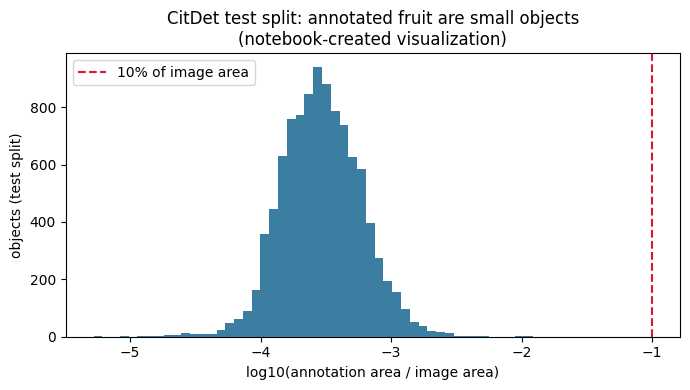

In [ ]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(np.log10(np.clip(frac, 1e-7, None)), bins=50, color="#3b7ea1")
ax.axvline(np.log10(0.10), color="crimson", linestyle="--", label="10% of image area")
ax.set_xlabel("log10(annotation area / image area)")
ax.set_ylabel("objects (test split)")
ax.set_title("CitDet test split: annotated fruit are small objects\n(notebook-created visualization)")
ax.legend()
plt.tight_layout()
plt.show()

### 6. Input preview with expert reference annotations

Before any analysis, preview three deterministic test images (first three image IDs, in annotation
order, that contain at least 5 boxes of each class) with their **ground-truth** boxes drawn:
red = `Fruit on Tree` (id 2), blue = `Fruit on Ground` (id 1). These are reference annotations from
the dataset, not model predictions.

**説明:** 各クラスのボックスを 5 つ以上含むテスト画像を ID 順に 3 枚選び、
**正解（リファレンス）アノテーション**を重ねて表示します。赤 = 樹上の果実、青 = 地上の果実です。

sample image ids: [0, 1, 2]


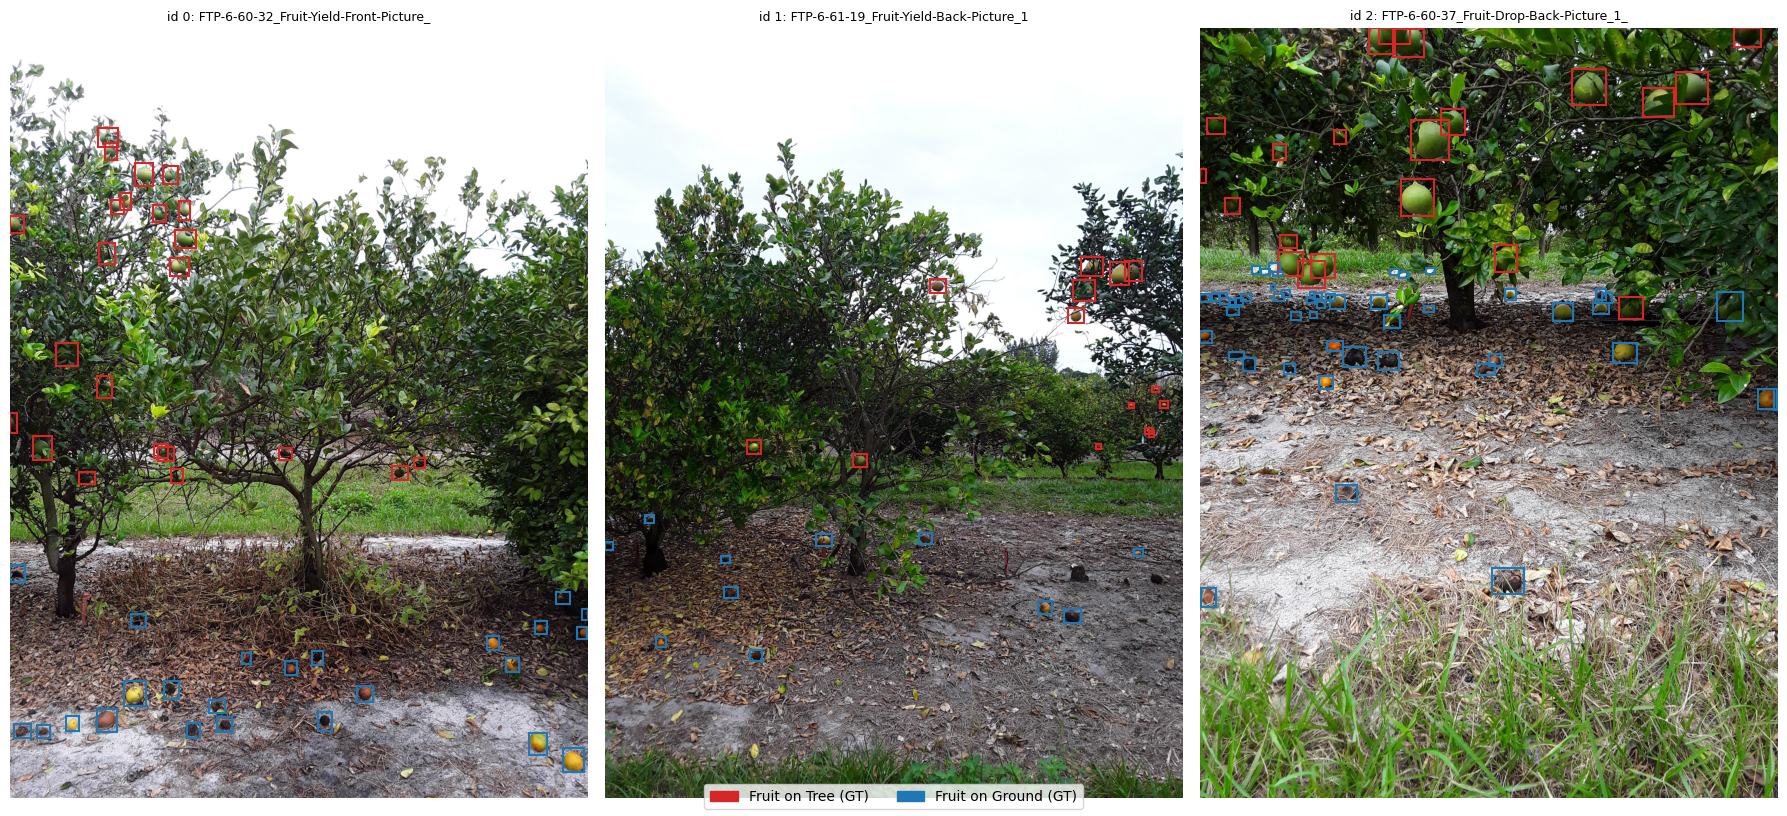

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image

def sample_ids_with_both_classes(coco, min_each=5, limit=3):
    chosen = []
    for img_id in sorted(coco.getImgIds()):
        anns = coco.loadAnns(coco.getAnnIds(imgIds=[img_id]))
        n = collections.Counter(a["category_id"] for a in anns)
        if n.get(1, 0) >= min_each and n.get(2, 0) >= min_each:
            chosen.append(img_id)
        if len(chosen) == limit:
            break
    return chosen

sample_ids = sample_ids_with_both_classes(coco_gt)
print("sample image ids:", sample_ids)

GT_COLORS = {1: "tab:blue", 2: "tab:red"}
GT_NAMES = {1: "Fruit on Ground (GT)", 2: "Fruit on Tree (GT)"}
fig, axes = plt.subplots(1, len(sample_ids), figsize=(6 * len(sample_ids), 8))
for ax, img_id in zip(np.atleast_1d(axes), sample_ids):
    info = coco_gt.loadImgs(img_id)[0]
    im = Image.open(os.path.join(CITDET_DIR, "test", "images", info["file_name"]))
    ax.imshow(im)
    for a in coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=[img_id])):
        x, y, w, h = a["bbox"]
        ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False, lw=1.5,
                                        edgecolor=GT_COLORS[a["category_id"]]))
    ax.set_title(f"id {img_id}: {info['file_name'][:38]}", fontsize=9)
    ax.axis("off")
handles = [mpatches.Patch(color="tab:red", label=GT_NAMES[2]),
           mpatches.Patch(color="tab:blue", label=GT_NAMES[1])]
fig.legend(handles=handles, loc="lower center", ncol=2)
plt.tight_layout()
plt.show()

### 7. Untrained baseline: COCO-pretrained Faster R-CNN (ADAPTED DEMONSTRATION)

**This is not the paper's model.** The authors fine-tuned YOLOv5/v7, DETR, YOLOS and Faster R-CNN on
CitDet and released no weights, so the paper's AP (e.g., YOLOv7-m tiled AP 0.455) cannot be reproduced
here. As a hands-on baseline we use torchvision's `fasterrcnn_resnet50_fpn` with COCO weights and use
its `'orange'` category as the nearest open-vocabulary stand-in for citrus fruit; every `'orange'`
detection is mapped to CitDet's `Fruit on Tree` (id 2) when scoring. Expect modest, clearly imperfect
results — the point is to exercise the dataset and the author's evaluation machinery end to end.

**説明:** 論文のモデルではありません。重み未公開のため再現不可能な AP の代わりに、
torchvision の COCO 事前学習済み Faster R-CNN を**未訓練ベースライン**として使用します
（COCO の `orange` クラスを柑橘の近似として採用し、評価時は CitDet の「Fruit on Tree」へ写像）。

In [ ]:
from torchvision.models.detection import fasterrcnn_resnet50_fpn, FasterRCNN_ResNet50_FPN_Weights

weights = FasterRCNN_ResNet50_FPN_Weights.COCO_V1
model = fasterrcnn_resnet50_fpn(weights=weights).to(device).eval()
coco_classes = weights.meta["categories"]
LABEL_ORANGE = coco_classes.index("orange")
print("COCO 'orange' label id:", LABEL_ORANGE)

predictions = {}
for img_id in sample_ids:
    info = coco_gt.loadImgs(img_id)[0]
    img = Image.open(os.path.join(CITDET_DIR, "test", "images", info["file_name"])).convert("RGB")
    with torch.inference_mode():
        pred = model([torchvision.transforms.functional.to_tensor(img).to(device)])[0]
    predictions[img_id] = pred
    n_orange = int((pred["labels"] == LABEL_ORANGE).sum())
    print(f"id {img_id}: {len(pred['boxes'])} raw detections, {n_orange} 'orange'")

Downloading: "https://download.pytorch.org/models/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth" to /root/.cache/torch/hub/checkpoints/fasterrcnn_resnet50_fpn_coco-258fb6c6.pth


  0%|          | 0.00/160M [00:00<?, ?B/s]

  5%|▍         | 7.75M/160M [00:00<00:01, 80.8MB/s]

 16%|█▌        | 25.4M/160M [00:00<00:00, 142MB/s] 

 28%|██▊       | 44.5M/160M [00:00<00:00, 168MB/s]

...

100%|██████████| 160M/160M [00:01<00:00, 157MB/s]

COCO 'orange' label id: 55


id 0: 28 raw detections, 6 'orange'


id 1: 27 raw detections, 6 'orange'


id 2: 42 raw detections, 7 'orange'


### 8. Detections versus reference annotations

Draw the baseline's `'orange'` detections (score ≥ 0.5, green) next to the ground truth for the first
sample image. Label the panels explicitly: left = reference annotations (dataset), right = untrained
model predictions.

**説明:** 先頭のサンプル画像について、ベースラインの検出結果（緑、score ≥ 0.5）と
正解アノテーションを並べて表示します。左 = 正解、右 = 未訓練モデルの予測です。

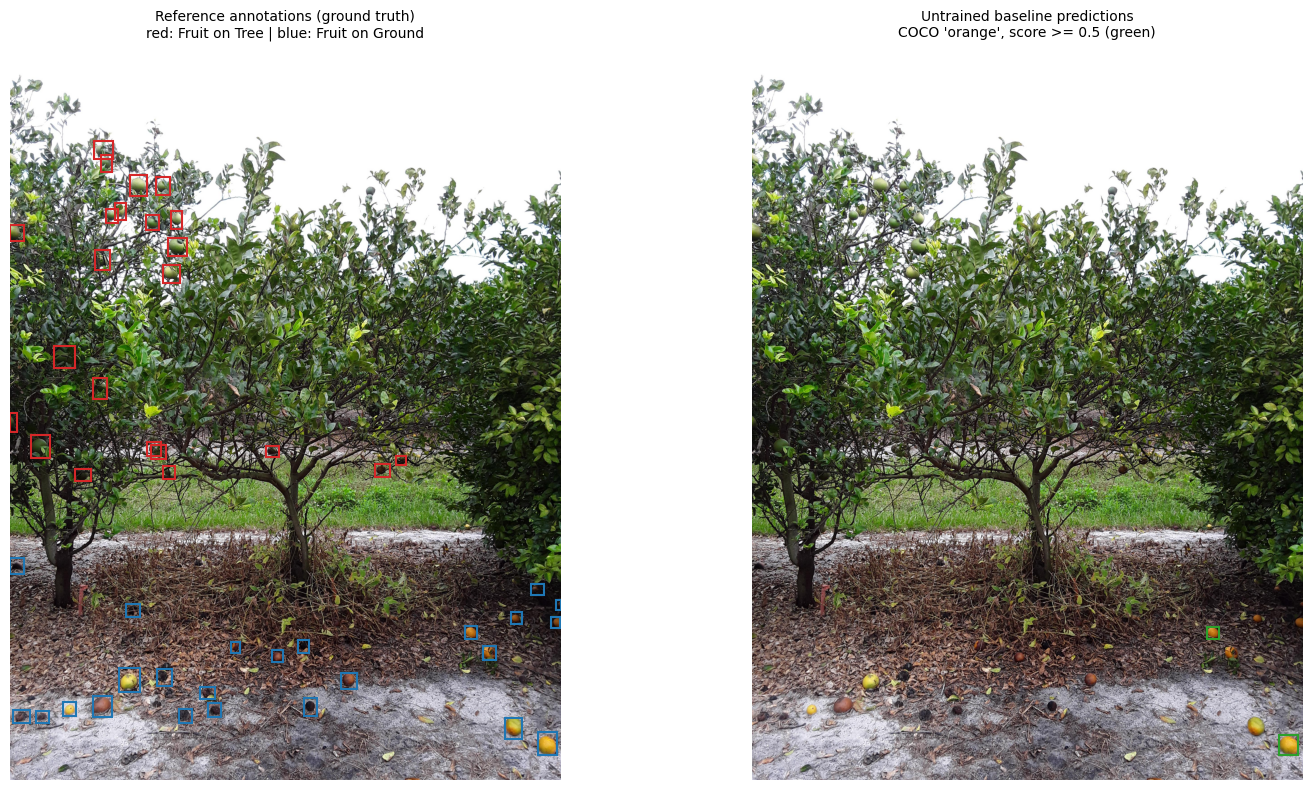

In [ ]:
SCORE_TH = 0.5

fig, axes = plt.subplots(1, 2, figsize=(16, 8))
img_id = sample_ids[0]
info = coco_gt.loadImgs(img_id)[0]
pil = Image.open(os.path.join(CITDET_DIR, "test", "images", info["file_name"]))

ax = axes[0]
ax.imshow(pil)
for a in coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=[img_id])):
    x, y, w, h = a["bbox"]
    ax.add_patch(mpatches.Rectangle((x, y), w, h, fill=False, lw=1.5, edgecolor=GT_COLORS[a["category_id"]]))
ax.set_title("Reference annotations (ground truth)\nred: Fruit on Tree | blue: Fruit on Ground", fontsize=10)
ax.axis("off")

ax = axes[1]
ax.imshow(pil)
pred = predictions[img_id]
keep = (pred["labels"] == LABEL_ORANGE) & (pred["scores"] >= SCORE_TH)
for box in pred["boxes"][keep].tolist():
    x1, y1, x2, y2 = box
    ax.add_patch(mpatches.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, lw=1.5, edgecolor="tab:green"))
ax.set_title(f"Untrained baseline predictions\nCOCO 'orange', score >= {SCORE_TH} (green)", fontsize=10)
ax.axis("off")
plt.tight_layout()
plt.show()

### 9. Score the baseline with the author's evaluation path

The author's `eval_coco_json.py` (pinned commit `55e46b7081a91c20f890dcb0c09a5f26e4a6d594`) evaluates a COCO-format prediction JSON
against ground truth with `COCOeval(..., 'bbox')`. We reuse exactly that path (inlined with
attribution because the script is 26 lines) and restrict it to the three sample images
(`imgIds`) and the `Fruit on Tree` category (`catIds=[2]`). The resulting AP is **not comparable** to
the paper's published AP: it covers 3 images and an untrained baseline.

**説明:** 著者の `eval_coco_json.py` と同一の COCOeval 手順でベースラインを採点します
（サンプル 3 枚・「Fruit on Tree」に限定）。論文の AP とは比較できません。

In [ ]:
from pycocotools.cocoeval import COCOeval

# Convert detections to COCO result format, mapped to "Fruit on Tree" (id 2)
results = []
for img_id in sample_ids:
    pred = predictions[img_id]
    for box, score, label in zip(pred["boxes"].tolist(), pred["scores"].tolist(), pred["labels"].tolist()):
        if label == LABEL_ORANGE and score >= SCORE_TH:
            x1, y1, x2, y2 = box
            results.append({"image_id": img_id, "category_id": 2,
                            "bbox": [x1, y1, x2 - x1, y2 - y1], "score": score})
print(f"{len(results)} predictions on {len(sample_ids)} images")

# --- Author's evaluation path (eval_coco_json.py) applied to the subset ---
coco_dt = coco_gt.loadRes(results)
coco_eval = COCOeval(coco_gt, coco_dt, "bbox")
coco_eval.params.imgIds = sample_ids
coco_eval.params.catIds = [2]  # Fruit on Tree
coco_eval.evaluate()
coco_eval.accumulate()
coco_eval.summarize()
baseline_ap = float(coco_eval.stats[0])

5 predictions on 3 images
Loading and preparing results...
DONE (t=0.00s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.01s).
Accumulating evaluation results...
DONE (t=0.01s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.002
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.004
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.000
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.003
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.000
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.009
 Average Recall     (AR) @[ IoU=0.50:0.95 

### 10. Results table and CSV export

Collect per-image ground-truth counts, untrained-baseline detection counts and the baseline AP into a
small table and export it as CSV in `/content` (downloadable from the Colab file browser).

**説明:** 各サンプル画像の正解件数・ベースライン検出件数・AP を表にまとめ、CSV として
`/content` に保存します（Colab のファイルブラウザからダウンロード可能）。

In [ ]:
import csv

rows = []
for img_id in sample_ids:
    info = coco_gt.loadImgs(img_id)[0]
    anns = coco_gt.loadAnns(coco_gt.getAnnIds(imgIds=[img_id]))
    n_gt = collections.Counter(a["category_id"] for a in anns)
    pred = predictions[img_id]
    keep = (pred["labels"] == LABEL_ORANGE) & (pred["scores"] >= SCORE_TH)
    rows.append({
        "image_id": img_id,
        "file_name": info["file_name"],
        "gt_fruit_on_tree": n_gt.get(2, 0),
        "gt_fruit_on_ground": n_gt.get(1, 0),
        "baseline_orange_detections@0.5": int(keep.sum()),
    })
print(f"untrained-baseline AP@[.5:.95] 'Fruit on Tree', {len(sample_ids)} images: {baseline_ap:.4f}")
print("paper reference (NOT comparable): YOLOv7-m fine-tuned, tiled AP 0.455 / whole AP 0.406 (RA-L 2024, Table II)")

results_csv = os.path.join(CITDET_DIR, "sample_results.csv")
with open(results_csv, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=list(rows[0].keys()))
    writer.writeheader()
    writer.writerows(rows)
print("saved:", results_csv)
pd.DataFrame(rows)

untrained-baseline AP@[.5:.95] 'Fruit on Tree', 3 images: 0.0020
paper reference (NOT comparable): YOLOv7-m fine-tuned, tiled AP 0.455 / whole AP 0.406 (RA-L 2024, Table II)
saved: /content/citdet/sample_results.csv


,image_id,file_name,gt_fruit_on_tree,gt_fruit_on_ground,baseline_orange_detections@0.5
0,0,FTP-6-60-32_Fruit-Yield-Front-Picture_1_2021-1...,23,24,2
1,1,FTP-6-61-19_Fruit-Yield-Back-Picture_1_2021-11...,14,11,2
2,2,FTP-6-60-37_Fruit-Drop-Back-Picture_1_2021-11-...,21,51,1


### 11. Interpretation and limitations

- **Verified in this notebook (measured, not cited):** the released archive matches the published
  split (460 train + 119 test = 579 images), the object-size claims (100% of test objects < 10% of
  image area; mean side ≈ 51.5 px ≈ the paper's "about 50×50"), and the 2-class taxonomy. Total
  released boxes = 42,653 (train 32,571 + test 10,082); the website's "over 32,000" holds while the
  PhenoPaper flow's "44,233" does not match the archive.
- **Not reproduced:** the paper's AP benchmarks (require fine-tuning YOLOv5/v7/DETR/YOLOS/Faster R-CNN
  on CitDet; no released weights), the tiled 3×3 variant, and the yield-estimation experiments
  (R² 0.754/0.793). The baseline AP shown above comes from 3 images and an untrained COCO model —
  it demonstrates the evaluation machinery only.
- **License:** dataset CC BY-NC-SA 4.0 (non-commercial); author code Apache-2.0.

**考察:** 本ノートブックで検証したのはデータセット統計と評価手順の実行です。論文の AP ベンチマーク
（ファインチューニングが必要・重み未公開）、タイリング実験、収量推定実験は未再現であり、
表示した AP は未訓練ベースライン・3 枚のサンプルに基づく参考値です。

### References

- J. A. James et al., "CitDet: A Benchmark Dataset for Citrus Fruit Detection," IEEE RA-L 9(12), 2024; arXiv:2309.05645v3.
- CitDet dataset, MavMatrix DOI 10.32855/dataset.2024.05.005 (V1), CC BY-NC-SA 4.0; also on USDA Ag Data Commons DOI 10.15482/USDA.ADC/1529611.
- Author code: robotic-vision-lab/CitDet-A-Benchmark-Dataset-For-Citrus-Fruit-Detection @ 55e46b7081a91c20f890dcb0c09a5f26e4a6d594 (Apache-2.0): `README.md`, `eval_coco_json.py`, `MANIFEST.TXT` (inside dataset), `train_eval_visualize.ipynb`.
- torchvision Faster R-CNN COCO weights (COCO_V1) and pycocotools — the evaluation library used by the authors.
- PhenoPaper investigation p-aec5f4a3b637086223a53c458d9c0bd3-20261007T141953Z-4159131 was used as prior research guidance only; all numbers above were re-measured from the downloaded bytes.
